In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
print(df.info())
print(df.describe())
print("Null values in each column:")
print(df.isnull().sum())

#We don't need the holiday column for our analysis, so we can drop it. and will use numeric features for our analysis.
df.drop('holiday', axis=1, inplace=True)
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB
None
               temp       rain_1h       snow_1h    clouds_all  traffic_volume
count  48204.000000  48204.000000  48204.000000  48204.000000    48204.000000
mean     281.205870      0.334264      0.000222     49.362231     3259.818355
std       13.338232     44.789133      0.008168     39.0

we have divided the traffic volume into classes as the classifiers we are using require them because they can't utilize continous numeric values qcut divides them in 3 equal groups based on the values in them

In [3]:
df["traffic_class"] = pd.qcut(df["traffic_volume"],q=3,labels=["Low", "Medium", "High"])

print(df["traffic_class"].value_counts())
print (df.head())

features = ["temp", "rain_1h", "snow_1h", "clouds_all"]
X = df[features]
y = df["traffic_class"]
print(X.head())
print(y.head())

traffic_class
Low       16070
Medium    16067
High      16067
Name: count, dtype: int64
     temp  rain_1h  snow_1h  clouds_all weather_main weather_description  \
0  288.28      0.0      0.0          40       Clouds    scattered clouds   
1  289.36      0.0      0.0          75       Clouds       broken clouds   
2  289.58      0.0      0.0          90       Clouds     overcast clouds   
3  290.13      0.0      0.0          90       Clouds     overcast clouds   
4  291.14      0.0      0.0          75       Clouds       broken clouds   

          date_time  traffic_volume traffic_class  
0   02/10/2012 9:00            5545          High  
1  02/10/2012 10:00            4516        Medium  
2  02/10/2012 11:00            4767          High  
3  02/10/2012 12:00            5026          High  
4  02/10/2012 13:00            4918          High  
     temp  rain_1h  snow_1h  clouds_all
0  288.28      0.0      0.0          40
1  289.36      0.0      0.0          75
2  289.58      0.0     

After we have the required columns and all preped we split the data into test and training data and scale them accordingly because the values go over a pretty big range

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    



Training set size: 38563
Testing set size: 9641


We will now try the classification through random forest classifiers

Accuracy: 47.22539155689244
Classification Report:
               precision    recall  f1-score   support

        High       0.46      0.44      0.45      3238
         Low       0.50      0.53      0.51      3197
      Medium       0.45      0.45      0.45      3206

    accuracy                           0.47      9641
   macro avg       0.47      0.47      0.47      9641
weighted avg       0.47      0.47      0.47      9641

['Low' 'High' 'High' 'Low' 'Low' 'Medium' 'High' 'Medium' 'Medium' 'High']
Confusion Matrix:
 [[1437  843  958]
 [ 730 1685  782]
 [ 943  832 1431]]


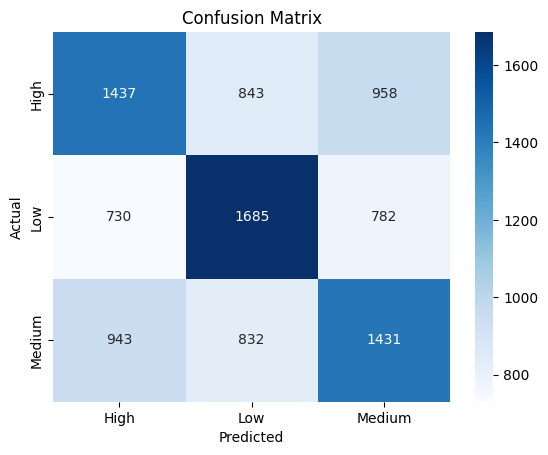

In [5]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_scaled, y_train)
y_pred = rf_classifier.predict(X_test_scaled)
print("Accuracy:", 100*accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print(y_pred[:10])
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

We now move on to trying to achieve the same using AdaBoost

Accuracy: 41.230162846177784
Classification Report:
               precision    recall  f1-score   support

        High       0.39      0.52      0.44      3238
         Low       0.48      0.37      0.42      3197
      Medium       0.39      0.35      0.37      3206

    accuracy                           0.41      9641
   macro avg       0.42      0.41      0.41      9641
weighted avg       0.42      0.41      0.41      9641

Confusion Matrix:
 [[1668  628  942]
 [1200 1191  806]
 [1443  647 1116]]


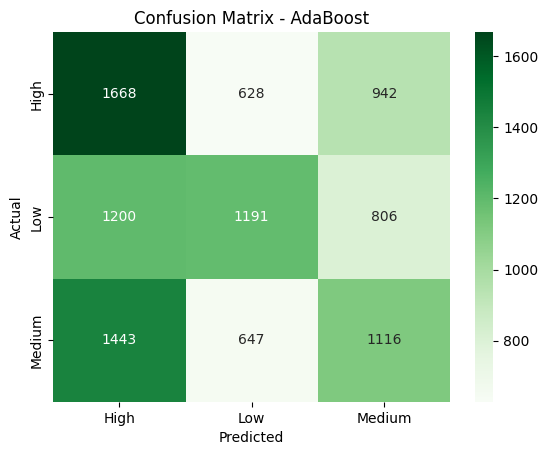

In [6]:
from sklearn.ensemble import AdaBoostClassifier
ada_classifier = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_classifier.fit(X_train_scaled, y_train)
y_pred_ada = ada_classifier.predict(X_test_scaled)
print("Accuracy:", 100*accuracy_score(y_test, y_pred_ada))
print("Classification Report:\n", classification_report(y_test, y_pred_ada))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
cm_ada = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Greens', xticklabels=ada_classifier.classes_, yticklabels=ada_classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AdaBoost')
plt.show()

Now an attempt to use XGboost and xgboost needs 0 1 2 not low medium and high 

['High' 'Low' 'Medium']
Accuracy: 45.555440307022096
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.45      0.45      3238
           1       0.48      0.58      0.52      3197
           2       0.44      0.34      0.38      3206

    accuracy                           0.46      9641
   macro avg       0.45      0.46      0.45      9641
weighted avg       0.45      0.46      0.45      9641

Confusion Matrix:
 [[1454  977  807]
 [ 768 1858  571]
 [1057 1069 1080]]


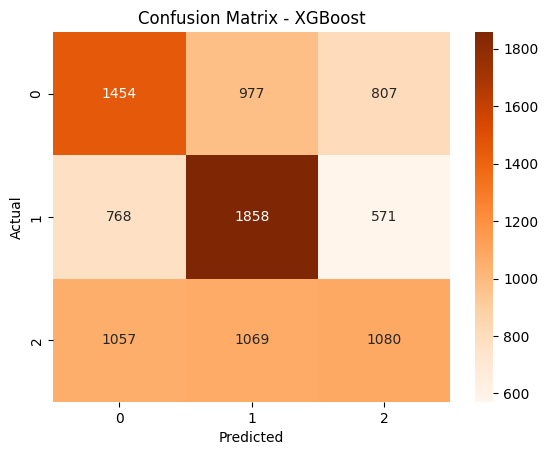

In [12]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
print(label_encoder.classes_)


xgb_classifier = XGBClassifier(n_estimators=100, random_state=42)
xgb_classifier.fit(X_train_scaled, y_train_encoded)
y_pred_xgb = xgb_classifier.predict(X_test_scaled)
print("Accuracy:", 100*accuracy_score(y_test_encoded, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred_xgb))
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=xgb_classifier.classes_, yticklabels=xgb_classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

We now compare the accuracy of the 3 models that we trained

Random Forest Accuracy: 47.22539155689244%
AdaBoost Accuracy: 41.230162846177784%
XGBoost Accuracy: 45.555440307022096%
       Algorithm  Accuracy (%)
0  Random Forest     47.225392
1       AdaBoost     41.230163
2        XGBoost     45.555440


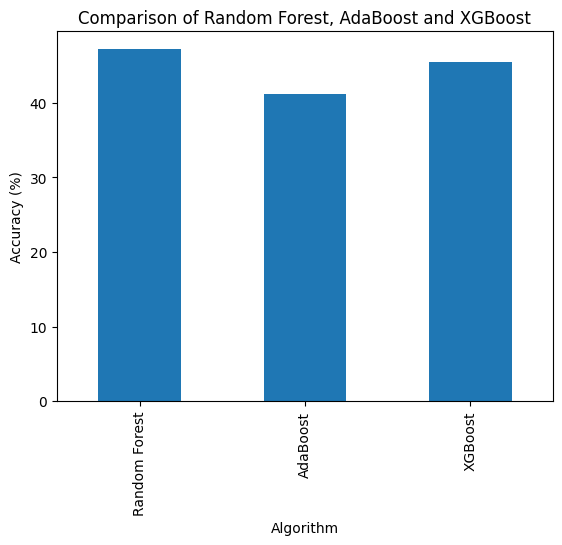

In [15]:
# Random Forest Accuracy
rf_accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {rf_accuracy*100}%")
# AdaBoost Accuracy
ada_accuracy = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Accuracy: {ada_accuracy*100}%")
# XGBoost Accuracy
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy*100}%")


results = pd.DataFrame({
    "Algorithm": ["Random Forest", "AdaBoost","XGBoost"],"Accuracy (%)": 
        [rf_accuracy * 100, ada_accuracy * 100, xgb_accuracy * 100]})

print(results)



results.plot(
    x="Algorithm",
    y="Accuracy (%)",
    kind="bar",
    legend=False
)

plt.title("Comparison of Random Forest, AdaBoost and XGBoost")
plt.ylabel("Accuracy (%)")
plt.show()